# HW 5: Modelling w/ NumPyro

# Part 1

In [1]:
# Imports

import numpy as np
import numpyro.distributions as dist
import numpyro
numpyro.set_host_device_count(2)
from numpyro import infer
import jax
import jax.numpy as jnp
from jax import random
print(jax.local_device_count())
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

2


## 1. Define Model
Use `NumPyro` to define a model containing a single random variable that follows a [Gamma](https://en.wikipedia.org/wiki/Gamma_distribution) [distribution]
(https://num.pyro.ai/en/stable/distributions.html#gamma) with shape parameters $\alpha=5$, $\beta=0.1$.  First draw samples directly from the distribution and plot the histogram and/or KDE.

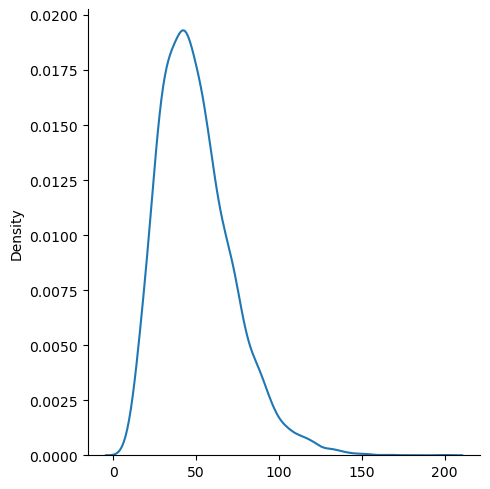

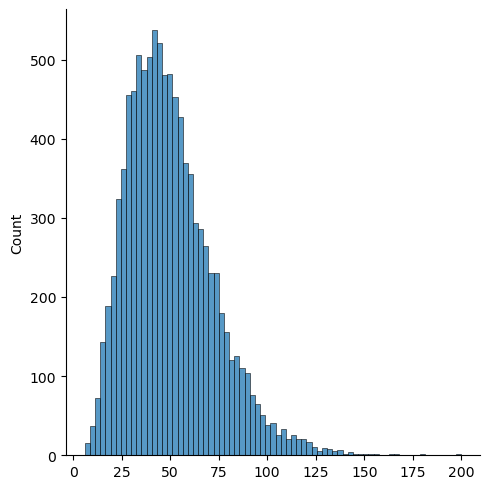

In [44]:
# generate rng
rng_key = random.PRNGKey(36) # 36 was the mnm racecar when I was small
rv = dist.Gamma(5,0.1)
samples = rv.sample(rng_key, (10000,))
sns.displot(samples, kind='kde');
sns.displot(samples);

In [45]:
def model(xdata=None):
    var = numpyro.sample("var", dist.Gamma(5,0.1))
    
    obs = numpyro.sample("obs", dist.Normal(μ, σ), obs=xdata)

## 2. Compute the Mean & Variance

Using the samples you've drawn, compute the mean and variance of the random variable. Modify the shape parameters individually to see how each of them affect the mean and variance of the distribution.

In [46]:
print('alpha = 5, beta = 0.1')
print(f'sample mean: {jnp.mean(samples)}')
print(f'sample variance: {jnp.var(samples)} \n')

alpha = 6
beta = 0.2
rv = dist.Gamma(alpha,beta)
samples = rv.sample(rng_key, (10000,))
print(f'alpha = {str(alpha)}, beta = {str(beta)}')
print(f'sample mean: {jnp.mean(samples)}')
print(f'sample variance: {jnp.var(samples)} \n')

alpha = 10
beta = 1
rv = dist.Gamma(alpha,beta)
samples = rv.sample(rng_key, (10000,))
print(f'alpha = {str(alpha)}, beta = {str(beta)}')
print(f'sample mean: {jnp.mean(samples)}')
print(f'sample variance: {jnp.var(samples)}')

alpha = 5, beta = 0.1
sample mean: 50.02872848510742
sample variance: 497.491943359375 

alpha = 6, beta = 0.2
sample mean: 30.002117156982422
sample variance: 149.08656311035156 

alpha = 10, beta = 1
sample mean: 10.009293556213379
sample variance: 9.929706573486328


In [47]:
# setting it back to normal
alpha = 5
beta = 0.1
rv = dist.Gamma(alpha,beta)
samples = rv.sample(rng_key, (10000,))

## 3. Make the Gamma Dist. Useful
The Gamma distribution doesn't have support for negative values, making it a useful prior distribution for parameters that must be positive.

##### a. Use `NumPyro` to conduct an MCMC sampling of our linear regression model with outliers from class, but replace the half-normal priors for standard deviation parameters with sensible gamma distributions (i.e., not dramatically different in scale from the half-normal distributions previously used).

In [48]:
# the linear regression model with outliers
def linear_model_w_outliers(x=None, y=None, σ_y=None):
    # First let's construct our foreground (i.e., linear) model
    m = numpyro.sample('m', dist.Uniform(0, 5))
    b = numpyro.sample('b', dist.Uniform(0, 500))
    μ_fg = m * x + b
    dist_fg = dist.Normal(μ_fg, σ_y)

    # Now lets define a model for the background (i.e., outliers)
    μ_bg = numpyro.sample('μ_bg', dist.Normal(loc=400, scale=500))
    σ_bg = numpyro.sample('σ_bg', dist.Gamma(0.5, 1))
    dist_bg = dist.Normal(μ_bg, jnp.sqrt(σ_bg**2 + σ_y**2))

    # We're going to assign each observation probabilistically to fg or bg using Categorical parameters
    ##3 a mixture of categorical distributions is a N-nomial distributions
    P_fg = numpyro.sample('P_fg', dist.Uniform(0, 1)) # Prob an observation will be in the foreground

    # Define the foreground/background parameters, with equal probability between categories
    mixing_dist = dist.Categorical(probs=jnp.array([P_fg, 1 - P_fg]))
    ### give it the prob of being in one model or the other and then give it the categories fo the model
    ### let the data tell us what is an outlier
    mixture = dist.MixtureGeneral(mixing_dist, [dist_fg, dist_bg])

    # Likelihood
    ### build giant distribution. this is the thing with 1 and 1-q in the other we saw above
    with numpyro.plate("data", len(x)):
        y_ = numpyro.sample("obs", mixture, obs=y) #y_ to disinguish from y

        # Until here, where we can track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        ### determinisitic is the thing that is going to marginalize over those, Re: The final equation above
        numpyro.deterministic(
            "log_p_fg", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

In [49]:
# I think we are using the same data set?

data = np.genfromtxt('../../../data/data_yerr.dat', names=True, comments='#', delimiter='&')
data

array([( 1., 201., 592., 61.), ( 2., 244., 401., 25.),
       ( 3.,  47., 583., 38.), ( 4., 287., 402., 15.),
       ( 5., 203., 495., 21.), ( 6.,  58., 173., 15.),
       ( 7., 210., 479., 27.), ( 8., 202., 504., 14.),
       ( 9., 198., 510., 30.), (10., 158., 416., 16.),
       (11., 165., 393., 14.), (12., 201., 442., 25.),
       (13., 157., 317., 52.), (14., 131., 311., 16.),
       (15., 166., 400., 34.), (16., 160., 337., 31.),
       (17., 186., 423., 42.), (18., 125., 334., 26.),
       (19., 218., 533., 16.), (20., 146., 344., 22.)],
      dtype=[('index', '<f8'), ('x', '<f8'), ('y', '<f8'), ('sigm_y', '<f8')])

In [50]:
numpyro.set_host_device_count(2)
jax.local_device_count()

2

In [51]:
rng_key, rng_key_ = random.split(rng_key)
numpyro.set_host_device_count(2)
kernel = infer.NUTS(linear_model_w_outliers)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=data['x'],
         y=data['y'],
         σ_y=data['sigm_y'])
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_fg      0.39      0.11      0.38      0.21      0.56   5852.03      1.00
         b    478.67     21.00    484.43    454.14    500.00    391.26      1.00
         m      0.15      0.11      0.12      0.00      0.27    420.61      1.00
      μ_bg    354.69     11.36    354.54    334.99    372.54   5454.64      1.00
      σ_bg     29.31      3.77     29.08     23.03     35.07   1589.59      1.00

Number of divergences: 0


In [ ]:
az.plot_trace(mcmc)
plt.tight_layout();

##### b. Does the change in prior distribution meaningfully change the posterior distributions?

<font color='orange'>By using the same data from the Modeling w/ Outliers notebook, chanigng the prior for the foreground and background model...</font>

<font color='orange'>The one on the left is from the prior for st dev set to the gamma distribution (RUN 2), on the right has the half normal prior (RUN 1)</font>

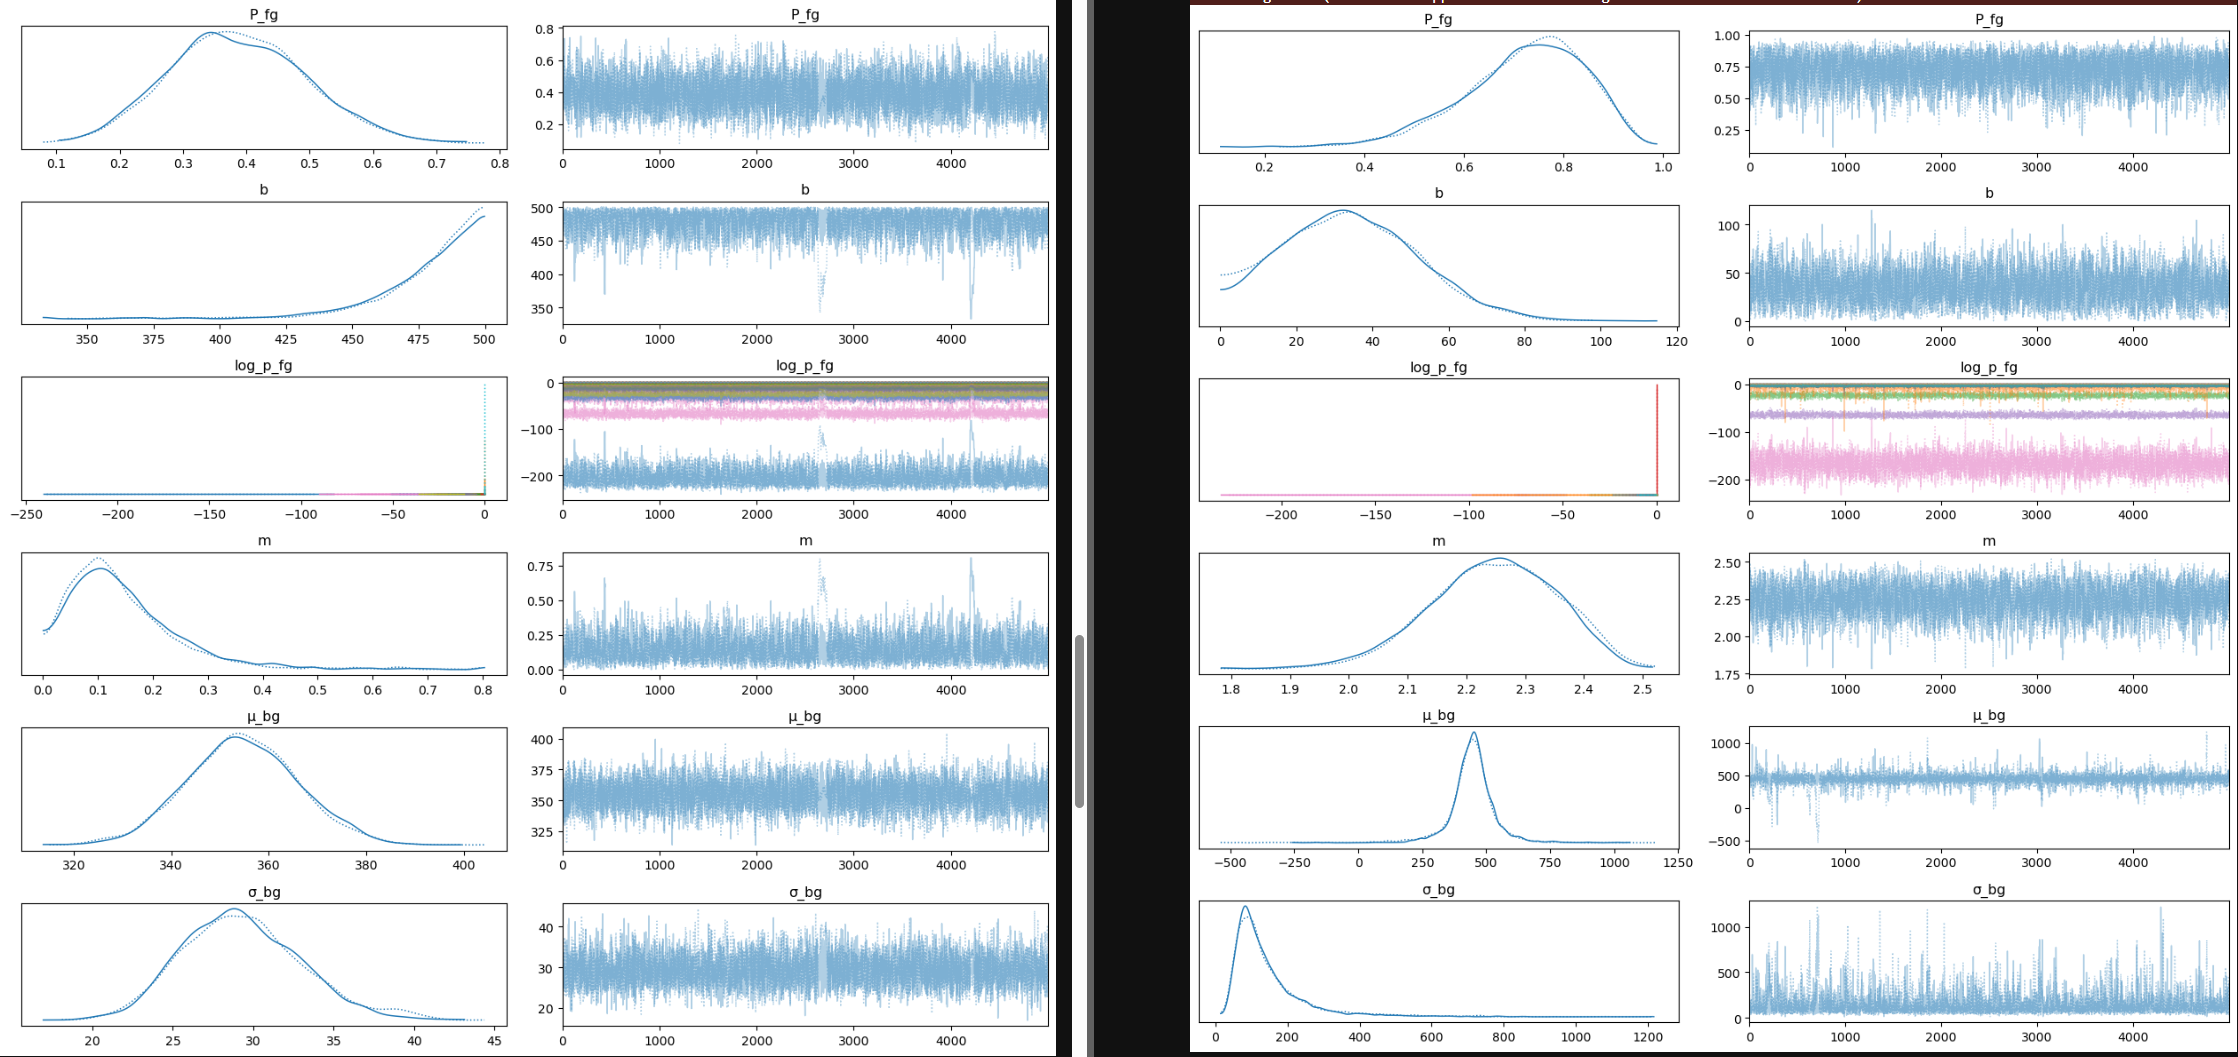

<div style="color: orange;">

The most positive changes are in:

- $\sigma_{bg}$ *looks* more constrained...however...*look at the x-axis*. The sampled span of the RUN 1 $\sigma_{bg}$ is huge! And it peaks around 100.  
  Even given that, RUN 2 constrains $\sigma_{bg}$ to a tighter region—one that is also contained within the RUN 1 peak.  
  So I would say RUN 2 does a better job at constraining $\sigma_{bg}$.

- $\mu_{bg}$ shares a similar story. RUN 1 has a huge spread. RUN 2 is more constrained and within what RUN 1 predicted.
    
Some neutral changes:
    
- $P_{fg}$ is similarly constrained between runs but they peak at different values. RUN 2 peaks at ~0.3 and RUN 1 peaks ~0.7 but each peak is contained within the distribution of the other.
    
- $\log(p_{fg})$ does not change

Some negative? changes:
    
- $b$ in RUN 2 spreads over the allowed range, railing at 500. In RUN 1, it seems to peak around ~30. I would also like to note that the RUN 2 range is waaay higher than the range of RUN 1. So I don't think RUN 2 does better at constraing this value. It just looks like perhaps a differnt prior or model would be useful for this one.

</div>


# Part 2 for Graduate Students

Repeat the Gaia linear regression analysis from the 564 portion of last week's homework, this time using `NumPyro`.

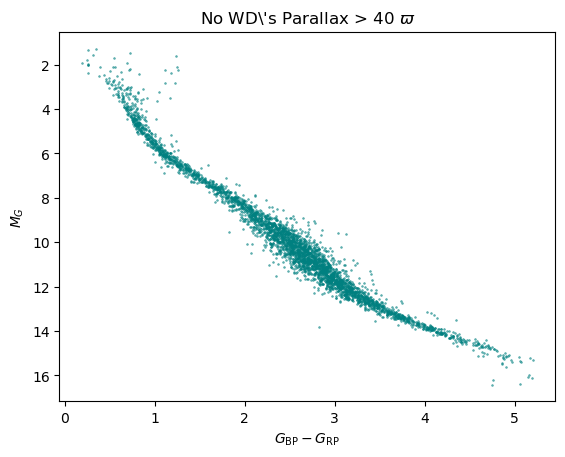

In [2]:
# first, step zero here, lets import the data
import pandas as pd
df = pd.read_csv('../../../../hub_data_share/gaiadr3_solar_neighborhood.csv')

# select only stars with parallax over 40
nearby_sel = df.parallax > 40
nearby_df = df[nearby_sel]

# remove white dwarfs
wd_color = (-0.4, 2)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) & (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

nearby_nowd_df = nearby_df[~wd_sel]

# ploit the data
plt.scatter(nearby_nowd_df.bp_rp, nearby_nowd_df.mg ,color='teal', marker='*', s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel(r'$G_\mathrm{BP} - G_\mathrm{RP}$')
plt.ylabel(r'$M_G$')
plt.title(r'No WD\'s Parallax > 40 $\varpi$')

xlim = plt.xlim()
plt.show()

##### *Define Model*

In [3]:
# define linear model just like we used last time
mag = jnp.array(nearby_nowd_df.mg.values)
color = jnp.array(nearby_nowd_df.bp_rp.values)
# without outlier analysis
def linear_model(color=None, mag=None):
    # priors
    m = numpyro.sample('m', dist.Normal(loc=4.0, scale=10))
    b = numpyro.sample('b', dist.Normal(loc=-1.0, scale=100))
    σ = numpyro.sample('scatter', dist.HalfNormal(scale=5))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", m * color + b)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(color)):
        obs = numpyro.sample('mag', dist.Normal(loc=μ, scale=σ), obs=mag)

##### *Do mcmc*

In [9]:
import time

start_time = time.time()

rng_key = random.PRNGKey(36)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         color=color,
         mag=mag)

print(time.time() - start_time)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

13.273148536682129

                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      2.58      0.03      2.58      2.54      2.62    869.41      1.00
         m      2.94      0.01      2.94      2.92      2.95    894.34      1.00
   scatter      0.56      0.01      0.56      0.55      0.58    978.76      1.00

Number of divergences: 0


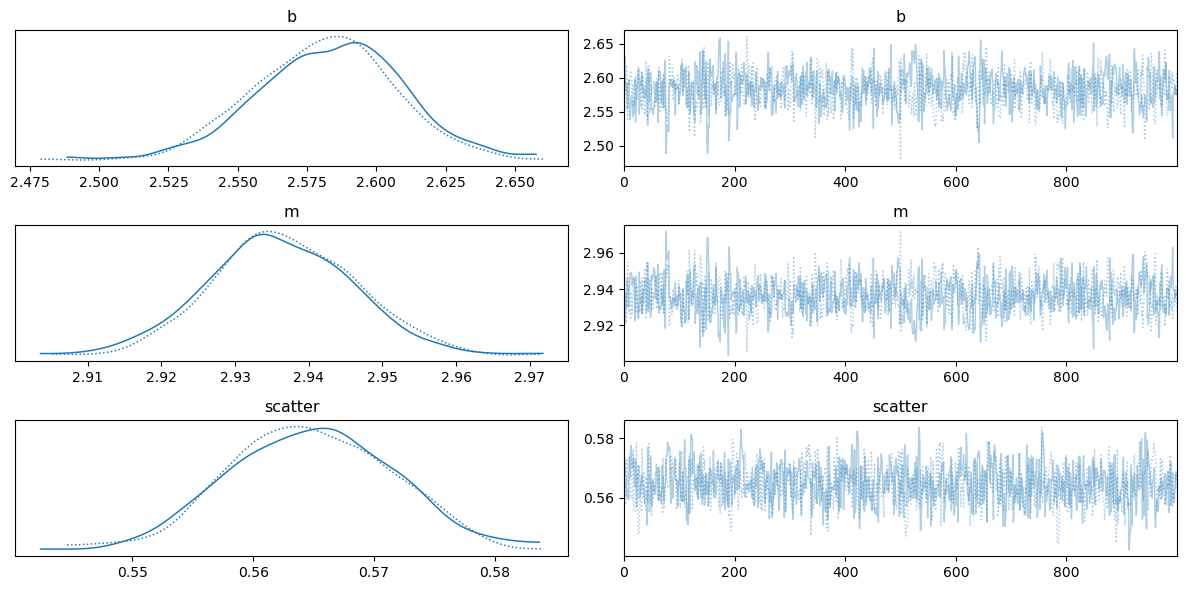

In [7]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

#### 1. How do your results compare?

#### 2. How about the efficiency of sampling?

In [10]:
import os
os.getpid()

3194

#### 3. Use the posterior predictive framework in `NumPyro` to simulate a new Gaia catalog from your model and posterior estimate.  How does it compare to the observed data?  How might we improve our model?

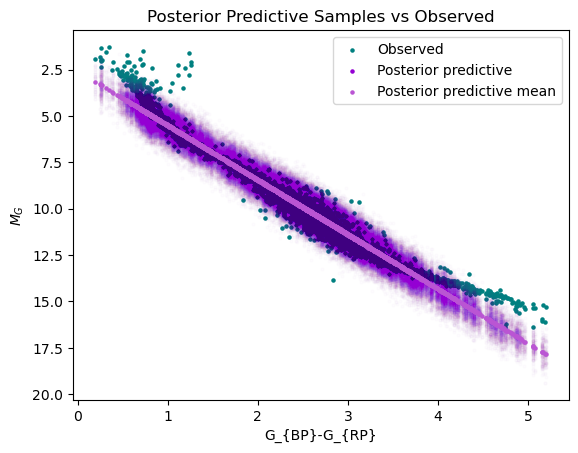

In [42]:
samples = mcmc.get_samples()

predictive = infer.Predictive(linear_model, posterior_samples=samples)

posterior_pred = predictive(rng_key_, color=color)

pred_mean = posterior_pred['mag'].mean(axis=0)

num_draws = 50  # how many posterior predictive draws to plot
draws_idx = np.random.choice(posterior_pred['mag'].shape[0], num_draws, replace=False)


plt.scatter(color, mag, s=5, alpha=1, color='teal', label='Observed')

plt.scatter([], [], s=5, alpha=1, color='darkviolet', label='Posterior predictive')

for i in draws_idx:
    plt.scatter(color, posterior_pred['mag'][i], s=5, alpha=0.01, color='darkviolet')
    
plt.scatter(color, pred_mean, s=5, alpha=1, color='mediumorchid' ,label='Posterior predictive mean')
plt.xlabel(r'G_{BP}-G_{RP}')
plt.ylabel(r'$M_G$')
plt.legend()
plt.gca().invert_yaxis()  # brighter stars at top
plt.title('Posterior Predictive Samples vs Observed')
plt.show()
